# Basic Eigenmode Simulation of Side-coupled Resonator

Two basic feeds on launcher-pads and routes shall be demonstrated

## Wirebond launcher

### Qiskit Metal Design

In [1]:
%load_ext autoreload
%autoreload 2
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
os.environ["PMIX_MCA_gds"]="hash"

# Import useful packages
import qiskit_metal as metal
from qiskit_metal import designs, draw
from qiskit_metal import MetalGUI, Dict, open_docs
from qiskit_metal.toolbox_metal import math_and_overrides
from qiskit_metal.qlibrary.core import QComponent
from collections import OrderedDict

# To create plots after geting solution data.
import matplotlib.pyplot as plt
import numpy as np

# Packages for the simple design
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.straight_path import RouteStraight
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.terminations.short_to_ground import ShortToGround
from qiskit_metal.qlibrary.couplers.coupled_line_tee import CoupledLineTee

# Set up chip design as planar, multiplanar also available
design = designs.DesignPlanar({}, overwrite_enabled=True)

# Set up chip dimensions 
design.chips.main.size.size_x = '4mm'
design.chips.main.size.size_y = '2.4mm'
design.chips.main.size.size_z = '500um'
design.chips.main.size.center_x = '0mm'
design.chips.main.size.center_y = '-1mm'

# Resonator and feedline gap width (W) and center conductor width (S) are set to 50 Ohm 
design.variables['cpw_width'] = '10 um' #S
design.variables['cpw_gap'] = '6 um' #W 

# Create GUI
gui = MetalGUI(design)

# Lauchpad 1
x1 = '-1.85mm'
y1 = '0mm'
launch_options1 = dict(chip='main', pos_x=x1, pos_y=y1, orientation='360', lead_length='30um', pad_height='100um', 
                      pad_width='103um', pad_gap='60um', taper_height='50um')
LP1 = LaunchpadWirebond(design, 'LP1', options = launch_options1)

# Launchpad 2
x2 = '1.85mm'
y1 = '0mm'
launch_options2 = dict(chip='main', pos_x=x2, pos_y=y1, orientation='180', lead_length='30um', pad_height='100um', 
                      pad_width='103um', pad_gap='60um', taper_height='50um')
LP2 = LaunchpadWirebond(design, 'LP2', options = launch_options2)

# Using path finder to connect the two launchpads
TL = RoutePathfinder(design, 'TL', options = dict(chip='main', trace_width ='10um',
                                            trace_gap ='6um',
                                            fillet='90um',                                                            
                                            hfss_wire_bonds = True,
                                            lead=dict(end_straight='0.1mm'),
                                            pin_inputs=Dict(
                                                start_pin=Dict(
                                                    component='LP1',
                                                    pin='tie'),
                                                end_pin=Dict(
                                                    component='LP2',
                                                    pin='tie')
                                            )))


######################
# lambda/4 resonator1#
######################
otg1 = OpenToGround(design, 'otg1', options=dict(chip='main', pos_x='-0.2mm',  pos_y='-40um', orientation = 180))
stg1 = ShortToGround(design, 'stg1', options=dict(chip='main', pos_x='0mm',  pos_y='-1.35mm', orientation = -90))

# Use RouteMeander to fix the total length of the resonator
res1 = RouteMeander(design, 'resonator1',  Dict(
        trace_width ='10um',
        trace_gap ='6um',
        total_length='3.7mm',
        hfss_wire_bonds = False,
        fillet='99.9 um',
        lead = dict(start_straight='300um'),
        pin_inputs=Dict(
        start_pin=Dict(component='otg1', pin='open'),
        end_pin=Dict(component='stg1', pin='short')), ))

# rebuild the GUI
gui.rebuild()

### Palace Eigenmode Simulation
(make sure to update the path to the Palace binary first)

In [ ]:
from SQDMetal.PALACE.Eigenmode_Simulation import PALACE_Eigenmode_Simulation
from SQDMetal.Utilities.Materials import MaterialInterface, MaterialConductor

#Eigenmode Simulation Options
user_defined_options = {
                 "mesh_refinement":  0,                             #refines mesh in PALACE - essetially divides every mesh element in half
                 "dielectric_material": "silicon",                  #choose dielectric material - 'silicon' or 'sapphire'
                 "starting_freq": 7e9,                              #starting frequency in Hz 
                 "number_of_freqs": 1,                              #number of eigenmodes to find
                 "solns_to_save": 1,                                #number of electromagnetic field visualizations to save
                 "solver_order": 2,                                 #increasing solver order increases accuracy of simulation, but significantly increases sim time
                 "solver_tol": 1.0e-8,                              #error residual tolerance foriterative solver
                 "solver_maxits": 200,                              #number of solver iterations
                 "fillet_resolution":12,                            #number of vertices per quarter turn on a filleted path
                 "palace_dir":"~/spack/opt/spack/linux-ubuntu24.04-zen2/gcc-13.3.0/palace-develop-36rxmgzatchgymg5tcbfz3qrmkf4jnmj/bin/palace",#"PATH/TO/PALACE/BINARY",
                 "num_cpus": 16                                     #number of cpus to use in the simulation
                }

#Creat the Palace Eigenmode simulation
eigen_sim = PALACE_Eigenmode_Simulation(name ='res_eigen_test',                              #name of simulation
                                        metal_design = design,                                      #feed in qiskit metal design
                                        sim_parent_directory = "",            #choose directory where mesh file, config file and HPC batch file will be saved
                                        mode = 'simPC',                                               #choose simulation mode 'HPC' or 'simPC'                                          
                                        meshing = 'GMSH',                                         #choose meshing 'GMSH' or 'COMSOL'
                                        user_options = user_defined_options,                        #provide options chosen above
                                        create_files = True)                                        #create mesh, config and HPC batch files

#Add in metals from layer 1 of the design file
eigen_sim.add_metallic(1)

#Add in ground plane for simulation
eigen_sim.add_ground_plane()

#Add in lumped element ports on launcher pads for 50 Ohm matching
eigen_sim.create_port_CPW_on_Launcher('LP1', 20e-6)
# eigen_sim.create_port_CPW_on_Launcher('LP2', 20e-6)
eigen_sim.create_CPW_feed_Uclip_on_Launcher('LP2', add_port=True)

#Fine mesh the resonator, launch apds and transmission line
eigen_sim.fine_mesh_components(['TL', 'resonator1', 'LP1', 'LP2'], min_size=8e-6, max_size=100e-6, taper_dist_min=10e-6, metals_only=False)

#Sets up the lossy interfaces for MA, SA and MS interfaces 
eigen_sim.setup_EPR_interfaces(metal_air=MaterialInterface('Aluminium-Vacuum'), substrate_air=MaterialInterface('Silicon-Vacuum'), substrate_metal=MaterialInterface('Silicon-Aluminium'))

#Only works in v0.14
# eigen_sim.set_farfield(ff_type='conductor', ff_material=MaterialConductor("OFHC"), ff_plane='z_neg')

#Prepares the mesh file and config file
eigen_sim.prepare_simulation()

In [ ]:
#run the simulation
eigen_sim.run()

The data will be stored in the output directory along with pregenerated plots slicing the device plane. Nonetheless, the slices can be manually retrieved via the `PVDVTU_Viewer` class. Either initialise the class directly or via the returned object when calling `retrieve_field_plots`:

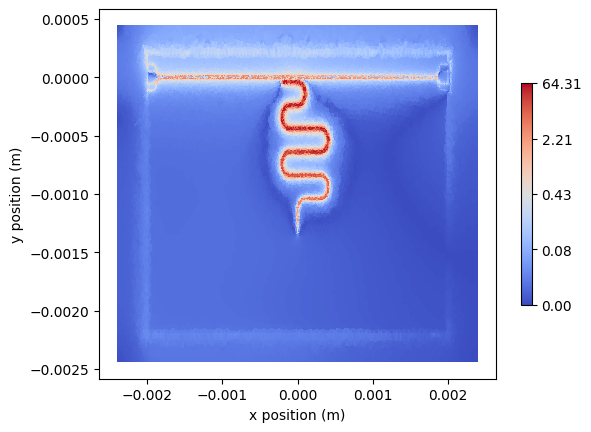

In [4]:
%matplotlib inline
pvdtu = eigen_sim.retrieve_field_plots()
leSlice = pvdtu.get_data_slice(0)
leSlice.plot(np.linalg.norm(leSlice.get_data('E_real'), axis=1), 'coolwarm', True);

## Routed path

### Qiskit Metal Design

In [1]:
%load_ext autoreload
%autoreload 2
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
os.environ["PMIX_MCA_gds"]="hash"

# Import useful packages
import qiskit_metal as metal
from qiskit_metal import designs, draw
from qiskit_metal import MetalGUI, Dict, open_docs
from qiskit_metal.toolbox_metal import math_and_overrides
from qiskit_metal.qlibrary.core import QComponent
from collections import OrderedDict

# To create plots after geting solution data.
import matplotlib.pyplot as plt
import numpy as np

# Packages for the simple design
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.straight_path import RouteStraight
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.terminations.short_to_ground import ShortToGround
from qiskit_metal.qlibrary.couplers.coupled_line_tee import CoupledLineTee
from SQDMetal.Comps.Joints import Joint

# Set up chip design as planar, multiplanar also available
design = designs.DesignPlanar({}, overwrite_enabled=True)

# Set up chip dimensions 
design.chips.main.size.size_x = '4mm'
design.chips.main.size.size_y = '2.4mm'
design.chips.main.size.size_z = '500um'
design.chips.main.size.center_x = '0mm'
design.chips.main.size.center_y = '-1mm'

# Resonator and feedline gap width (W) and center conductor width (S) are set to 50 Ohm 
design.variables['cpw_width'] = '10 um' #S
design.variables['cpw_gap'] = '6 um' #W 

# Create GUI
gui = MetalGUI(design)

# Lauchpad 1
Joint(design, 'LP1', options=dict(pos_x='-2mm',pos_y='0mm'))

# Launchpad 2
Joint(design, 'LP2', options=dict(pos_x='2mm',pos_y='0mm',orientation=180))

# Using path finder to connect the two launchpads
TL = RoutePathfinder(design, 'TL', options = dict(chip='main', trace_width ='10um',
                                            trace_gap ='6um',
                                            fillet='90um',                                                            
                                            hfss_wire_bonds = True,
                                            lead=dict(end_straight='0.1mm'),
                                            pin_inputs=Dict(
                                                start_pin=Dict(
                                                    component='LP1',
                                                    pin='a'),
                                                end_pin=Dict(
                                                    component='LP2',
                                                    pin='a')
                                            )))


######################
# lambda/4 resonator1#
######################
otg1 = OpenToGround(design, 'otg1', options=dict(chip='main', pos_x='-0.2mm',  pos_y='-40um', orientation = 180))
stg1 = ShortToGround(design, 'stg1', options=dict(chip='main', pos_x='0mm',  pos_y='-1.35mm', orientation = -90))

# Use RouteMeander to fix the total length of the resonator
res1 = RouteMeander(design, 'resonator1',  Dict(
        trace_width ='10um',
        trace_gap ='6um',
        total_length='3.7mm',
        hfss_wire_bonds = False,
        fillet='99.9 um',
        lead = dict(start_straight='300um'),
        pin_inputs=Dict(
        start_pin=Dict(component='otg1', pin='open'),
        end_pin=Dict(component='stg1', pin='short')), ))

# rebuild the GUI
gui.rebuild()

### Palace Eigenmode Simulation
(make sure to update the path to the Palace binary first)

In [ ]:
from SQDMetal.PALACE.Eigenmode_Simulation import PALACE_Eigenmode_Simulation
from SQDMetal.Utilities.Materials import MaterialInterface, MaterialConductor

#Eigenmode Simulation Options
user_defined_options = {
                 "mesh_refinement":  0,                             #refines mesh in PALACE - essetially divides every mesh element in half
                 "dielectric_material": "silicon",                  #choose dielectric material - 'silicon' or 'sapphire'
                 "starting_freq": 7.6e9,                              #starting frequency in Hz 
                 "number_of_freqs": 1,                              #number of eigenmodes to find
                 "solns_to_save": 1,                                #number of electromagnetic field visualizations to save
                 "solver_order": 2,                                 #increasing solver order increases accuracy of simulation, but significantly increases sim time
                 "solver_tol": 1.0e-8,                              #error residual tolerance foriterative solver
                 "solver_maxits": 200,                              #number of solver iterations
                 "fillet_resolution":12,                            #number of vertices per quarter turn on a filleted path
                 "palace_dir":"~/spack/opt/spack/linux-ubuntu24.04-zen2/gcc-13.3.0/palace-develop-36rxmgzatchgymg5tcbfz3qrmkf4jnmj/bin/palace",#"PATH/TO/PALACE/BINARY",
                 "num_cpus": 16                                     #number of cpus to use in the simulation
                }

#Creat the Palace Eigenmode simulation
eigen_sim = PALACE_Eigenmode_Simulation(name ='res_eigen_test',                              #name of simulation
                                        metal_design = design,                                      #feed in qiskit metal design
                                        sim_parent_directory = "",            #choose directory where mesh file, config file and HPC batch file will be saved
                                        mode = 'simPC',                                               #choose simulation mode 'HPC' or 'simPC'                                          
                                        meshing = 'GMSH',                                         #choose meshing 'GMSH' or 'COMSOL'
                                        user_options = user_defined_options,                        #provide options chosen above
                                        create_files = True)                                        #create mesh, config and HPC batch files

#Add in metals from layer 1 of the design file
eigen_sim.add_metallic(1)

#Add in ground plane for simulation
eigen_sim.add_ground_plane()

#Add in lumped element ports on launcher pads for 50 Ohm matching
eigen_sim.create_port_CPW_on_Route('TL', 'start', 20e-6)
# eigen_sim.create_port_CPW_on_Route('TL', 'end', 20e-6)
eigen_sim.create_CPW_feed_Uclip_on_Route('TL', 'end', add_port=True)

#Fine mesh the resonator, launch apds and transmission line
eigen_sim.fine_mesh_components(['TL', 'resonator1'], min_size=8e-6, max_size=100e-6, taper_dist_min=10e-6, metals_only=False)

#Sets up the lossy interfaces for MA, SA and MS interfaces 
eigen_sim.setup_EPR_interfaces(metal_air=MaterialInterface('Aluminium-Vacuum'), substrate_air=MaterialInterface('Silicon-Vacuum'), substrate_metal=MaterialInterface('Silicon-Aluminium'))

#Only works in v0.14
# eigen_sim.set_farfield(ff_type='conductor', ff_material=MaterialConductor("OFHC"), ff_plane='z_neg')

#Prepares the mesh file and config file
eigen_sim.prepare_simulation()

In [ ]:
#run the simulation
eigen_sim.run()

The data will be stored in the output directory along with pregenerated plots slicing the device plane. Nonetheless, the slices can be manually retrieved via the `PVDVTU_Viewer` class. Either initialise the class directly or via the returned object when calling `retrieve_field_plots`:

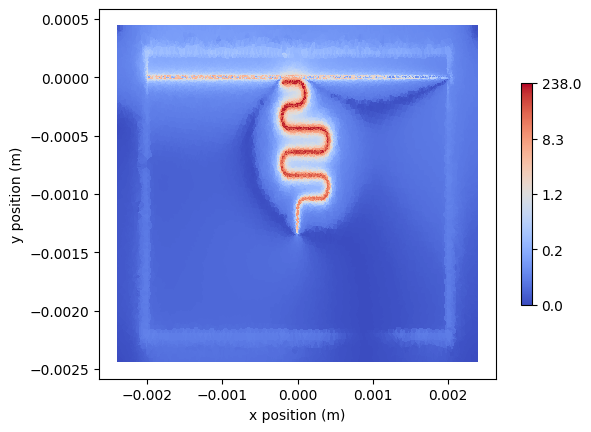

In [4]:
%matplotlib inline
pvdtu = eigen_sim.retrieve_field_plots()
leSlice = pvdtu.get_data_slice(0)
leSlice.plot(np.linalg.norm(leSlice.get_data('E_real'), axis=1), 'coolwarm', True);